In [ ]:
#"F:\SimpliLearn_2024_2025\Capstone_ILT_Materials\Batch1\Images.zip"

In [7]:
import sys
sys.executable

'c:\\Users\\srini\\anaconda3\\envs\\genai\\python.exe'

In [8]:
import shutil
shutil.unpack_archive(r"C:\Users\srini\Downloads\Datasets (1)\Capstone 1\Part 1\Images.zip")

In [11]:
import pandas as pd
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

ModuleNotFoundError: No module named 'cv2'

In [4]:
labels_df = pd.read_csv(r"C:\Users\srini\Downloads\labels.csv",sep=",", header=None)

In [49]:
labels_df.head()

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45


In [29]:
labels_df.columns = ['image_id',"class","x_min","y_min","x_max","y_max"]

In [30]:
labels_df.head()

,image_id,class,x_min,y_min,x_max,y_max
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45


In [31]:
labels_df["image_id"] = labels_df["image_id"].apply(lambda x:f"{x:08d}")

In [32]:
labels_df.head(10)

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45
5,00000001,bus,205,155,568,314
6,00000001,bus,285,123,477,168
7,00000001,car,544,162,617,193
8,00000001,car,329,152,371,163
9,00000001,car,447,161,497,183


In [37]:
labels_df = labels_df.iloc[:1000]

In [38]:
images_dir = "Images/"

In [39]:
#images = []
images228 = []
images480 = []

In [40]:
labels_df.iterrows()

<generator object DataFrame.iterrows at 0x000001C10A6442E0>

In [41]:
# for index,row in labels_df.iterrows():
#     #print(index,row["image_id"])
#     image_path = os.path.join(images_dir, f"{row["image_id"]}.jpg")
#     img = cv2.imread(image_path)
#     if img is not None:
#         images.append(img)
#     else:
#         print(f"Error laoding image,{image_path}")


In [42]:
#images = np.array(images)

In [43]:
images[0].shape

NameError: name 'images' is not defined

In [44]:
images[10].shape

NameError: name 'images' is not defined

In [45]:
for index,row in labels_df.iterrows():
    #print(index,row["image_id"])
    image_path = os.path.join(images_dir, f"{row["image_id"]}.jpg")
    img = cv2.imread(image_path)
    if img is not None:
        if len(img) == 228:
            images228.append(img)
        else:
            images480.append(img)
            
    else:
        print(f"Error laoding image,{image_path}")

SyntaxError: f-string: unmatched '[' (1914775755.py, line 3)

In [28]:
if len(images228) == 0:
    print("No images loaded")
else:
    print(f"{len(images228)} images loaded successfully")

206 images loaded successfully


In [29]:
if len(images480) == 0:
    print("No images loaded")
else:
    print(f"{len(images480)} images loaded successfully")

794 images loaded successfully


In [31]:
vehicle_type = labels_df["class"].value_counts()
print(vehicle_type)

class
car                      682
pickup_truck             111
motorized_vehicle         61
articulated_truck         30
work_van                  29
bus                       28
pedestrian                23
single_unit_truck         18
bicycle                   12
non-motorized_vehicle      5
motorcycle                 1
Name: count, dtype: int64


In [32]:
labels_df = labels_df.sort_values("image_id")

In [36]:
if len(images228) > 0:
    processed_images = [cv2.resize(img,(224,224)) for img in images228]

In [37]:
if len(images480) > 0:
    processed_images.extend([cv2.resize(img,(224,224)) for img in images480])

In [38]:
len(processed_images)

1000

In [39]:
type(processed_images)

list

In [40]:
processed_images = np.array(processed_images)

In [42]:
labels_df.head()

,image_id,class,x_min,y_min,x_max,y_max
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45


In [44]:
labels = labels_df["class"].to_numpy()



In [45]:
bounding_boxes = labels_df[['x_min','y_min','x_max','y_max']].to_numpy()

In [46]:
len(labels)

1000

In [62]:
labels

array(['pickup_truck', 'car', 'car', 'articulated_truck', 'car', 'bus',
       'bus', 'car', 'car', 'car', 'car', 'motorized_vehicle', 'car',
       'car', 'bus', 'car', 'articulated_truck', 'car', 'car',
       'pickup_truck', 'car', 'car', 'car', 'car', 'car', 'car', 'car',
       'car', 'car', 'car', 'car', 'car', 'car', 'car', 'pickup_truck',
       'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car',
       'pickup_truck', 'car', 'car', 'car', 'bus', 'articulated_truck',
       'work_van', 'motorized_vehicle', 'car', 'motorized_vehicle', 'car',
       'car', 'articulated_truck', 'car', 'car', 'car', 'car', 'car',
       'car', 'motorized_vehicle', 'car', 'bus', 'bus', 'car', 'car',
       'car', 'car', 'motorized_vehicle', 'pickup_truck', 'car',
       'pickup_truck', 'car', 'car', 'pickup_truck', 'car',
       'single_unit_truck', 'single_unit_truck', 'car', 'car', 'car',
       'car', 'pickup_truck', 'car', 'car', 'car', 'car', 'car', 'car',
       'car', 'car', 'car',

In [48]:
unique_labels = np.unique(labels)

In [49]:
labels_to_index = {label: index for index , label in enumerate(unique_labels)}

In [50]:
labels_to_index

{'articulated_truck': 0,
 'bicycle': 1,
 'bus': 2,
 'car': 3,
 'motorcycle': 4,
 'motorized_vehicle': 5,
 'non-motorized_vehicle': 6,
 'pedestrian': 7,
 'pickup_truck': 8,
 'single_unit_truck': 9,
 'work_van': 10}

In [63]:
labels = np.array([labels_to_index[label]  for label in labels])

In [69]:
labels

array([ 8,  3,  3,  0,  3,  2,  2,  3,  3,  3,  3,  5,  3,  3,  2,  3,  0,
        3,  3,  8,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        8,  3,  3,  3,  3,  3,  3,  3,  3,  3,  8,  3,  3,  3,  2,  0, 10,
        5,  3,  5,  3,  3,  0,  3,  3,  3,  3,  3,  3,  5,  3,  2,  2,  3,
        3,  3,  3,  5,  8,  3,  8,  3,  3,  8,  3,  9,  9,  3,  3,  3,  3,
        8,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  0,  3,  3,  3,  8,  3,
        3,  9,  3,  3,  8,  3,  3,  3,  8,  8,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  8, 10,  3,  3,  3,  3,  3,  3,  5,  2,  3,  3, 10,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  5,  3,  3,  7,  5,  3,  3,  8,  3,
        3,  8,  3,  3,  5,  3,  3,  3,  8,  8, 10,  8,  8,  3,  8,  3,  3,
        3,  5,  3,  5,  5,  8,  3,  8,  8,  3,  3, 10,  0,  5,  3,  8,  3,
        5,  3,  3,  3,  3,  8,  3,  8,  3,  3,  8,  8,  3,  8, 10,  3,  3,
        8,  3,  8,  3,  3,  3,  3,  3,  3,  3,  3,  3,  5,  0,  1,  3,  3,
        3,  3,  3,  3,  3

In [70]:
X_train,X_test,y_train,y_test,bbox_train,bbox_test = train_test_split(processed_images,labels,bounding_boxes,test_size=0.2,random_state=42)

In [77]:
len(y_train)

800

In [78]:
len(y_test)

200

In [79]:
y_test

array([ 3,  3,  8,  7,  3,  3,  3,  3,  3,  3,  3,  3,  3,  0,  3,  0,  3,
        3,  3,  3,  3,  5,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  8, 10,
        3,  8,  3,  3,  9,  3,  3,  0,  8,  8,  3,  3,  3,  8,  5,  3,  3,
        3,  3,  8,  3,  3, 10,  3,  3,  3,  3,  3,  3,  3,  3,  8,  3,  3,
        3,  8,  3,  3,  3,  3, 10,  2,  3,  3,  3,  3,  3,  2,  3,  3,  3,
        0,  3,  3,  7,  2,  3,  3,  3,  1,  2,  5,  3,  3,  5,  4,  5,  3,
        3,  5,  8,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  8,  2,  8, 10,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  8,  8,  5,  2,  3,  8,  3, 10, 10,  5,  3,  3,  3,  3,
        5,  3,  1,  8,  8,  3,  3,  1,  3,  8,  3,  9,  3,  3,  5,  3,  3,
        8,  3,  8,  3,  7,  1, 10,  3,  3,  3,  9,  3,  5,  2,  8,  3,  3,
        7,  3,  3, 10,  3,  3,  3,  3,  8,  3,  3,  3,  3])

## CNN Architecture

In [88]:
def create_model(input_shape, num_class):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32,(3,3),activation="relu")(inputs)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(64,(3,3),activation="relu")(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(64,(3,3),activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64,activation="relu")(x)
    vehicle_class = layers.Dense(num_class, activation="softmax",name="vehicle_class")(x)
    bounding_box = layers.Dense(4,name="bounding_box")(x)
    model = keras.Model(inputs=inputs, outputs=[vehicle_class,bounding_box])
    return model
    



In [89]:
input_shape = processed_images[0].shape

num_classes = len(unique_labels)



In [90]:
model = create_model(input_shape,num_classes)

In [91]:
model.compile(optimizer="adam", loss={"vehicle_class":"sparse_categorical_crossentropy", "bounding_box":"mse"},
              metrics={"vehicle_class":"accuracy", "bounding_box":"mae"})

In [92]:
model.fit(X_train,{"vehicle_class":y_train, "bounding_box":bbox_train},epochs=100,validation_data=(X_test,{"vehicle_class":y_test,"bounding_box":bbox_test}))

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 811ms/step - bounding_box_loss: 358941.8438 - bounding_box_mae: 282.0621 - loss: 359175.0000 - vehicle_class_accuracy: 0.2037 - vehicle_class_loss: 233.1630 - val_bounding_box_loss: 30442.4688 - val_bounding_box_mae: 137.1902 - val_loss: 30098.2246 - val_vehicle_class_accuracy: 0.0050 - val_vehicle_class_loss: 183.1584
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 820ms/step - bounding_box_loss: 28011.4121 - bounding_box_mae: 129.9168 - loss: 28178.5703 - vehicle_class_accuracy: 0.4363 - vehicle_class_loss: 167.1586 - val_bounding_box_loss: 31807.9551 - val_bounding_box_mae: 135.6930 - val_loss: 31249.1191 - val_vehicle_class_accuracy: 0.6800 - val_vehicle_class_loss: 119.9597
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 824ms/step - bounding_box_loss: 27191.3926 - bounding_box_mae: 128.8754 - loss: 27319.5117 - vehicle_class_accuracy: 0.6150 - vehicle_class_loss: 128.1255 - val_bounding_box_loss: 31919.8965 - val_bounding_box_mae: 134.0504 - val_l

In [93]:
model.evaluate(X_test,{"vehicle_class":y_test,"bounding_box":bbox_test},verbose=2)

7/7 - 1s - 169ms/step - bounding_box_loss: 29697.7461 - bounding_box_mae: 129.6097 - loss: 28885.4629 - vehicle_class_accuracy: 0.5650 - vehicle_class_loss: 3.7340


[28885.462890625,
 3.7339987754821777,
 29697.74609375,
 129.6096649169922,
 0.5649999976158142]

In [95]:
# Run inferences 

import matplotlib.pyplot as plt

# Choose a few sample images for inference
sample_images = X_test[:5]  # Adjust the number of sample images as needed

# Perform inference on the sample images
predictions = model.predict(sample_images)

# Extract the predicted bounding box coordinates
predicted_bounding_boxes = predictions[1]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


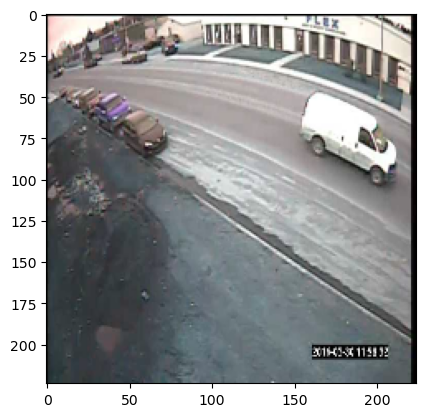

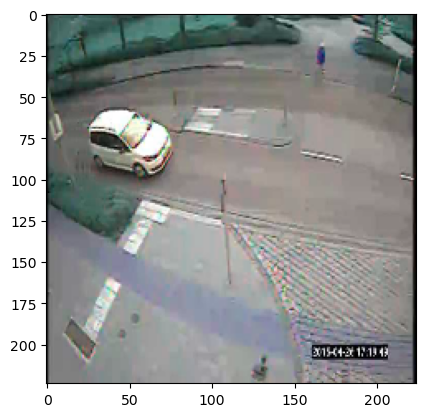

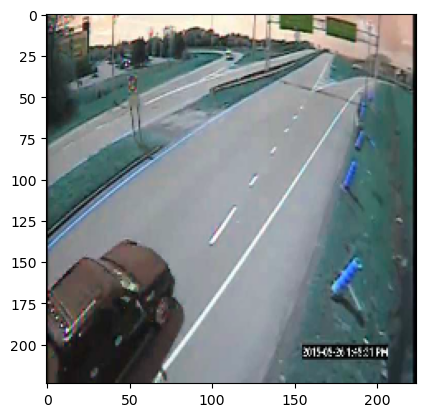

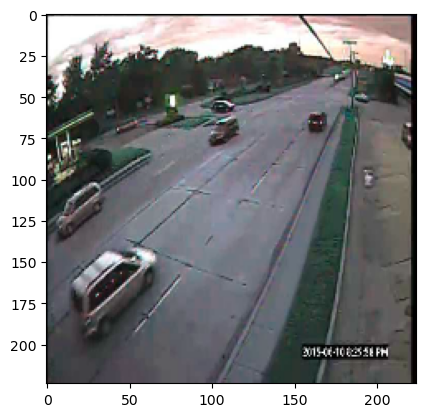

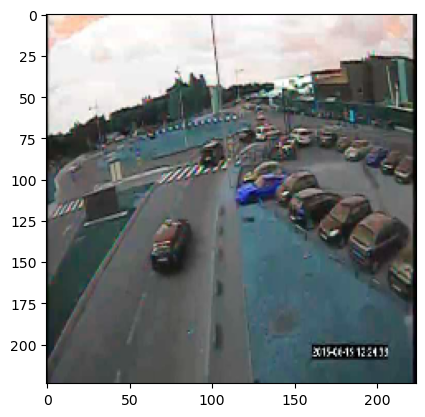

In [96]:
# Visualize the sample images with predicted bounding boxes
for i in range(len(sample_images)):
    plt.figure()
    plt.imshow(sample_images[i])
    plt.gca().add_patch(plt.Rectangle((predicted_bounding_boxes[i][0], predicted_bounding_boxes[i][1]),
                                     predicted_bounding_boxes[i][2] - predicted_bounding_boxes[i][0],
                                     predicted_bounding_boxes[i][3] - predicted_bounding_boxes[i][1], 
                                     fill=False, edgecolor='r', linewidth=2))
    plt.show()

## Tesla

In [ ]:
"F:\SimpliLearn_2024_2025\Capstone_ILT_Materials\Batch1\Tesla - Deaths.csv"

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\deepk\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\deepk\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\deepk\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\deepk\AppData\Roaming\nltk_data...


In [121]:
data = pd.read_csv(r"F:\SimpliLearn_2024_2025\Capstone_ILT_Materials\Batch1\Tesla - Deaths.csv")

In [122]:
data.head()

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,...,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN


# perform preliminary data inspection checking for data types, missing values, duplicates

In [123]:
missing_values = data.isna()

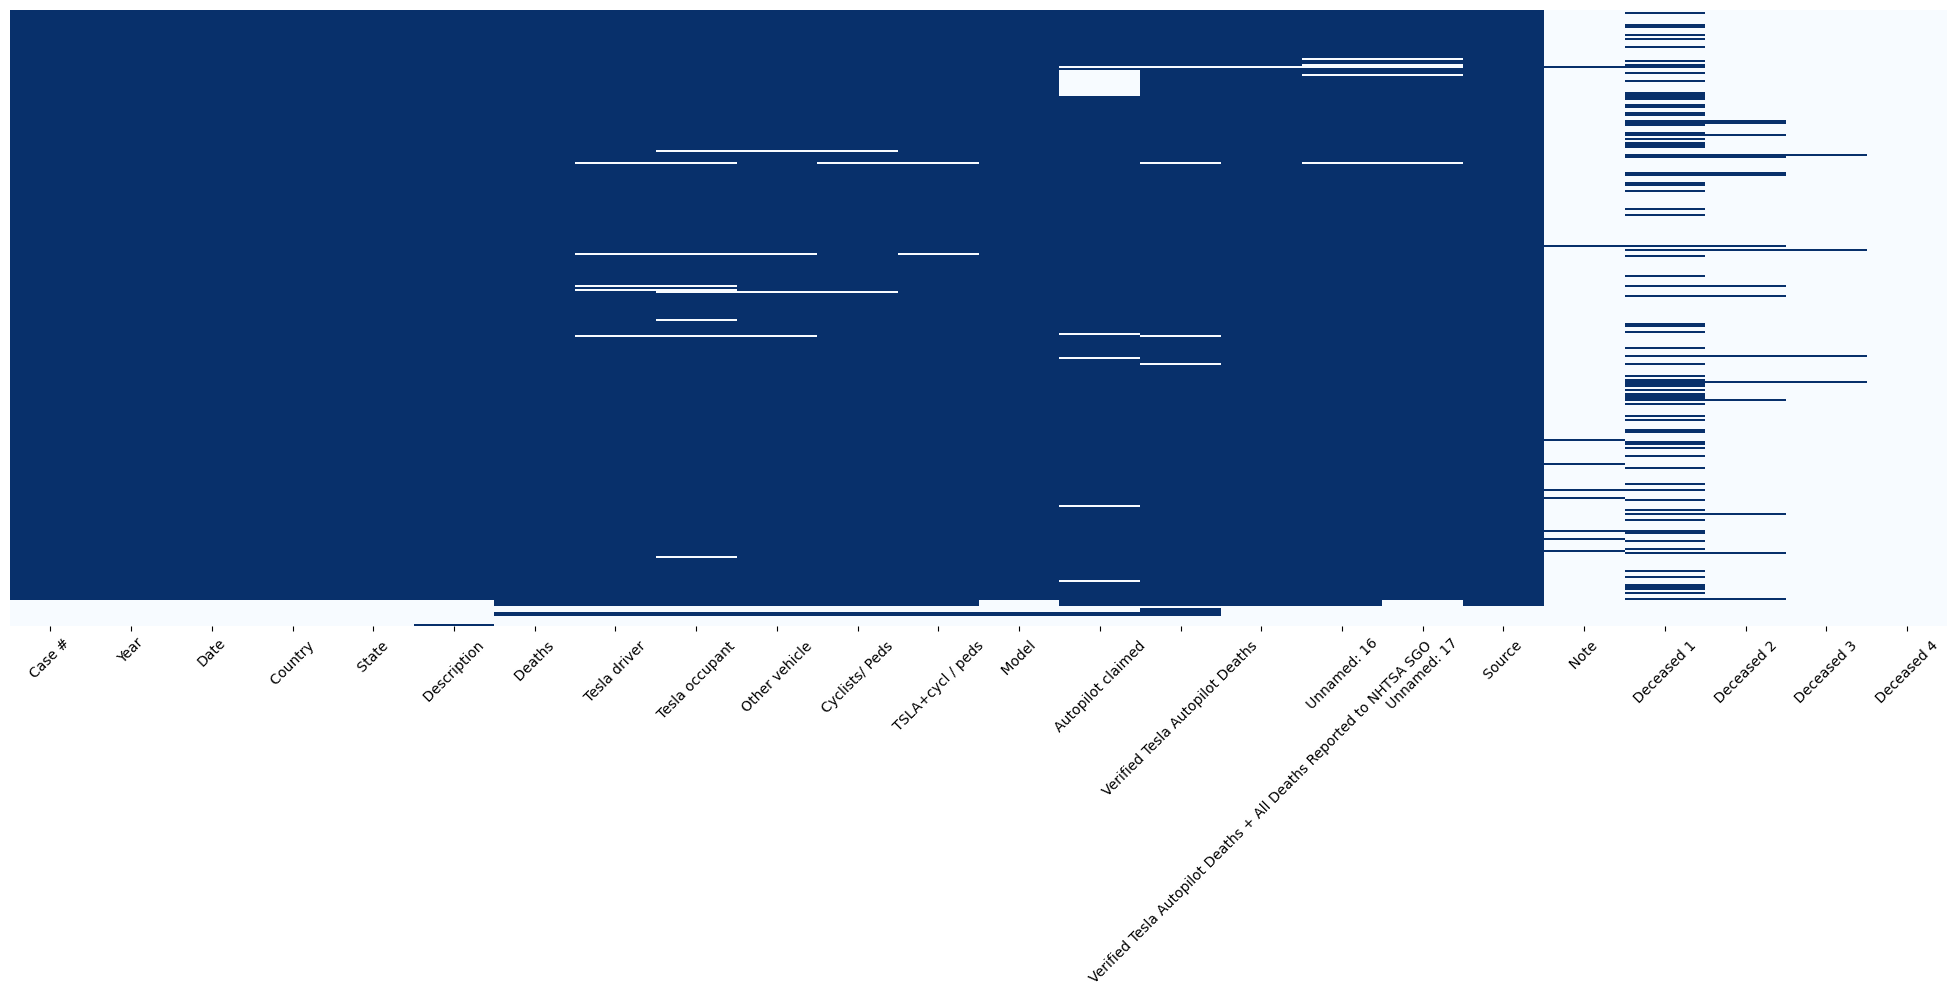

In [124]:
plt.figure(figsize=(25,8))
sns.heatmap(missing_values,cmap="Blues_r", cbar=False)
plt.tick_params(left=False, labelleft=False)
plt.xticks(rotation=45)
plt.show()

In [125]:
data.isna().sum()

Case #                                                                   13
Year                                                                     13
Date                                                                     13
 Country                                                                 13
 State                                                                   13
 Description                                                             12
 Deaths                                                                   8
 Tesla driver                                                            13
 Tesla occupant                                                          17
 Other vehicle                                                           12
 Cyclists/ Peds                                                          11
 TSLA+cycl / peds                                                        10
 Model                                                                   11
 Autopilot c

In [126]:
data.columns

Index(['Case #', 'Year', 'Date', ' Country ', ' State ', ' Description ',
       ' Deaths ', ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths ',
       ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ',
       'Unnamed: 16', 'Unnamed: 17', ' Source ', ' Note ', ' Deceased 1 ',
       ' Deceased 2 ', ' Deceased 3 ', ' Deceased 4 '],
      dtype='object')

In [127]:
data.shape

(307, 24)

In [128]:
drop_columns = ["Case #", "Year","Unnamed: 16","Unnamed: 17",' Source ',' Note ', ' Deceased 1 ',
       ' Deceased 2 ', ' Deceased 3 ', ' Deceased 4 ']

In [129]:
data.drop(columns=drop_columns, inplace=True)

In [130]:
data[' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO '].value_counts(dropna=False)

 Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO 
 -       269
  1       21
NaN       11
  2        3
  3        1
  24       1
  27       1
Name: count, dtype: int64

In [131]:
data.drop(columns=' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ',inplace=True)

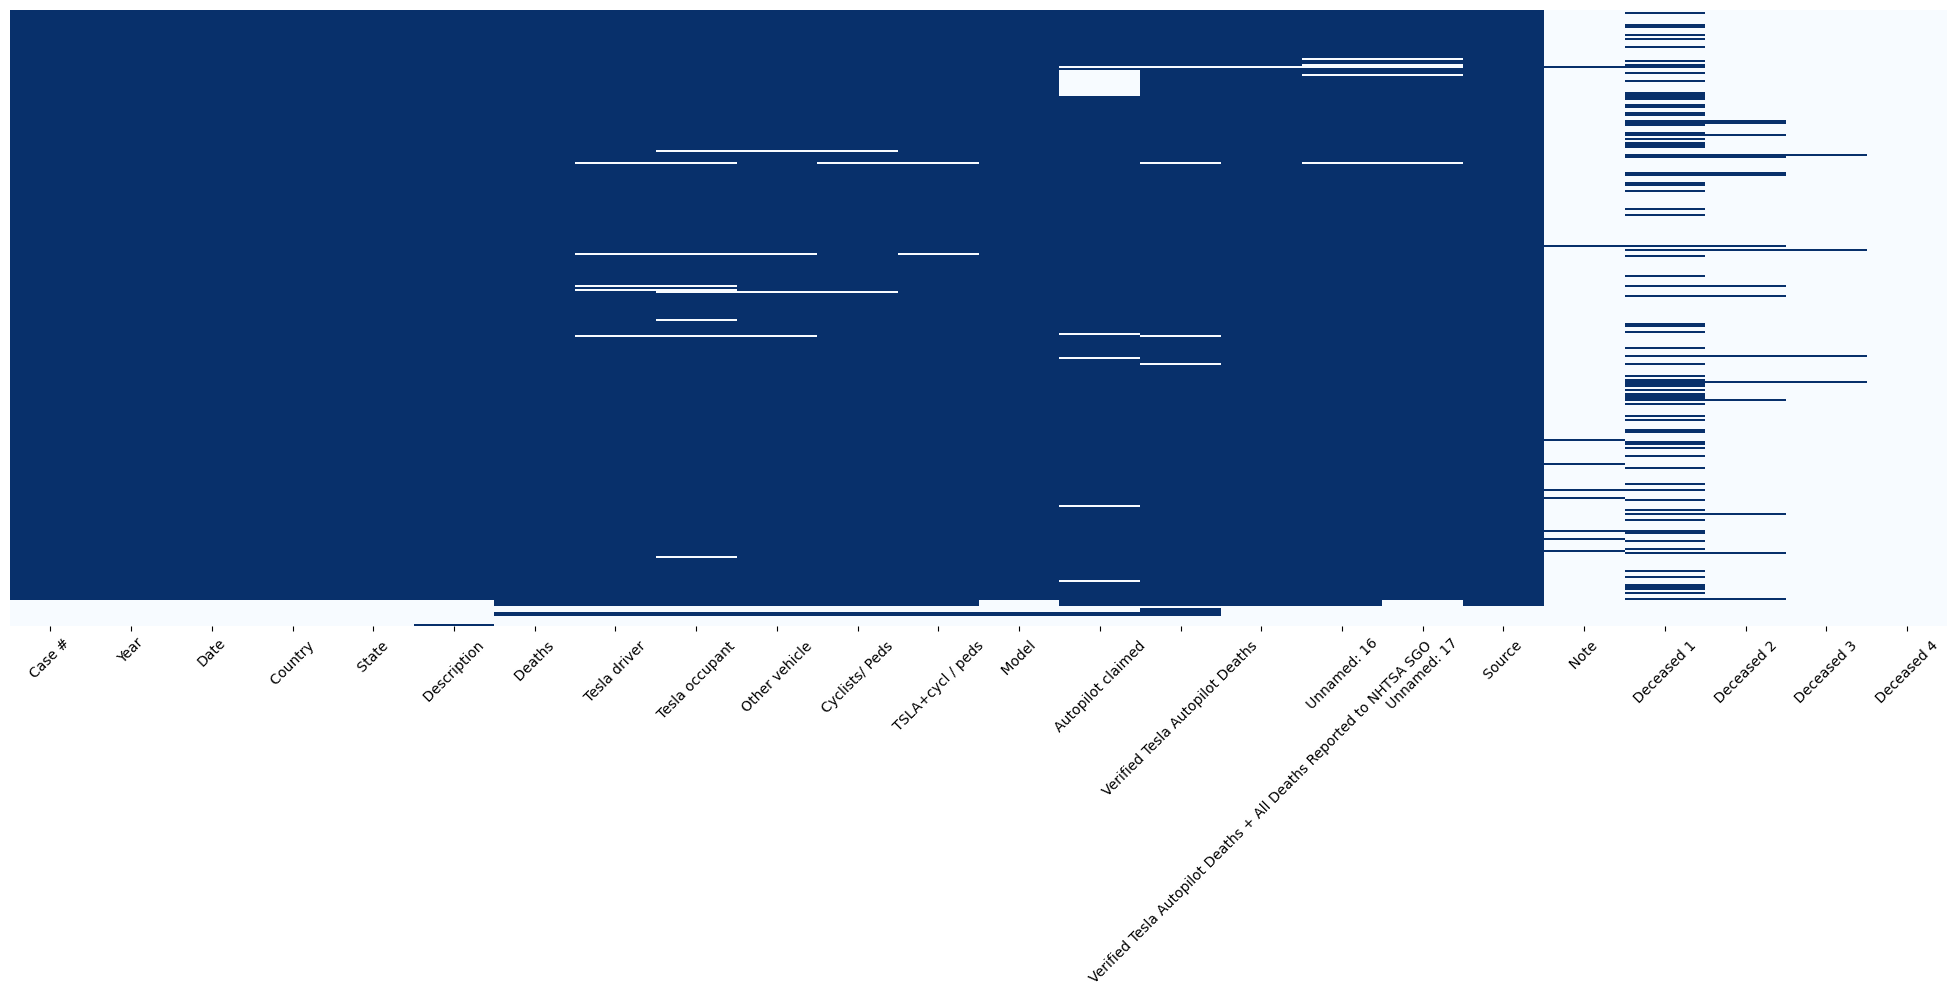

In [132]:
plt.figure(figsize=(25,8))
sns.heatmap(missing_values,cmap="Blues_r", cbar=False)
plt.tick_params(left=False, labelleft=False)
plt.xticks(rotation=45)
plt.show()

In [133]:
data.head()

,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths
0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,-,1,-,-,-
1,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,-,1,-,-,-
2,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,-,1,-,-,-
3,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,-,1,-,-,-
4,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,1,1,-,-,-


In [134]:
data[" Model "].value_counts()

 Model 
 -       181
 S        45
  3       39
 X        17
 Y        10
  2        1
  1        1
  50       1
2019       1
Name: count, dtype: int64

In [135]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               294 non-null    object 
 1    Country                           294 non-null    object 
 2    State                             294 non-null    object 
 3    Description                       295 non-null    object 
 4    Deaths                            299 non-null    float64
 5    Tesla driver                      294 non-null    object 
 6    Tesla occupant                    290 non-null    object 
 7    Other vehicle                     295 non-null    object 
 8    Cyclists/ Peds                    296 non-null    object 
 9    TSLA+cycl / peds                  297 non-null    object 
 10   Model                             296 non-null    object 
 11   Autopilot claimed                 281 non-null    object 

In [136]:
data.columns

Index(['Date', ' Country ', ' State ', ' Description ', ' Deaths ',
       ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ',
       ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ',
       ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths '],
      dtype='object')

In [137]:
cols = data.columns[5:]
for col in cols:
    if col != ' Model ':
        print(col)
        data[col] = data[col].fillna("-")
        data[col] = data[col].str.strip()
        data[col] = data[col].replace("-","0")
        data[col] = data[col].astype(int)
        print(data[col].unique())

 Tesla driver 
[   1    0   28   89  117    6 2014]
 Tesla occupant 
[   0    1    3    2    7   41   48    5 2015]
 Other vehicle 
[   0    1    2    3    4   29  101  130   16 2016]
 Cyclists/ Peds 
[   0    1    2   20   26   46   11 2017]
 TSLA+cycl / peds 
[   1    0    2    3    4   61  149  210   21 2018]
 Autopilot claimed 
[   0    1    2    8   30   38   47 2020]
 Verified Tesla Autopilot Deaths 
[   0    1    2    3   16   19  118 2022   75 2021]


In [138]:
data.isna().sum()

Date                                 13
 Country                             13
 State                               13
 Description                         12
 Deaths                               8
 Tesla driver                         0
 Tesla occupant                       0
 Other vehicle                        0
 Cyclists/ Peds                       0
 TSLA+cycl / peds                     0
 Model                               11
 Autopilot claimed                    0
 Verified Tesla Autopilot Deaths      0
dtype: int64

In [139]:
data.dropna(inplace=True)

In [141]:
missing_values = data.isna()

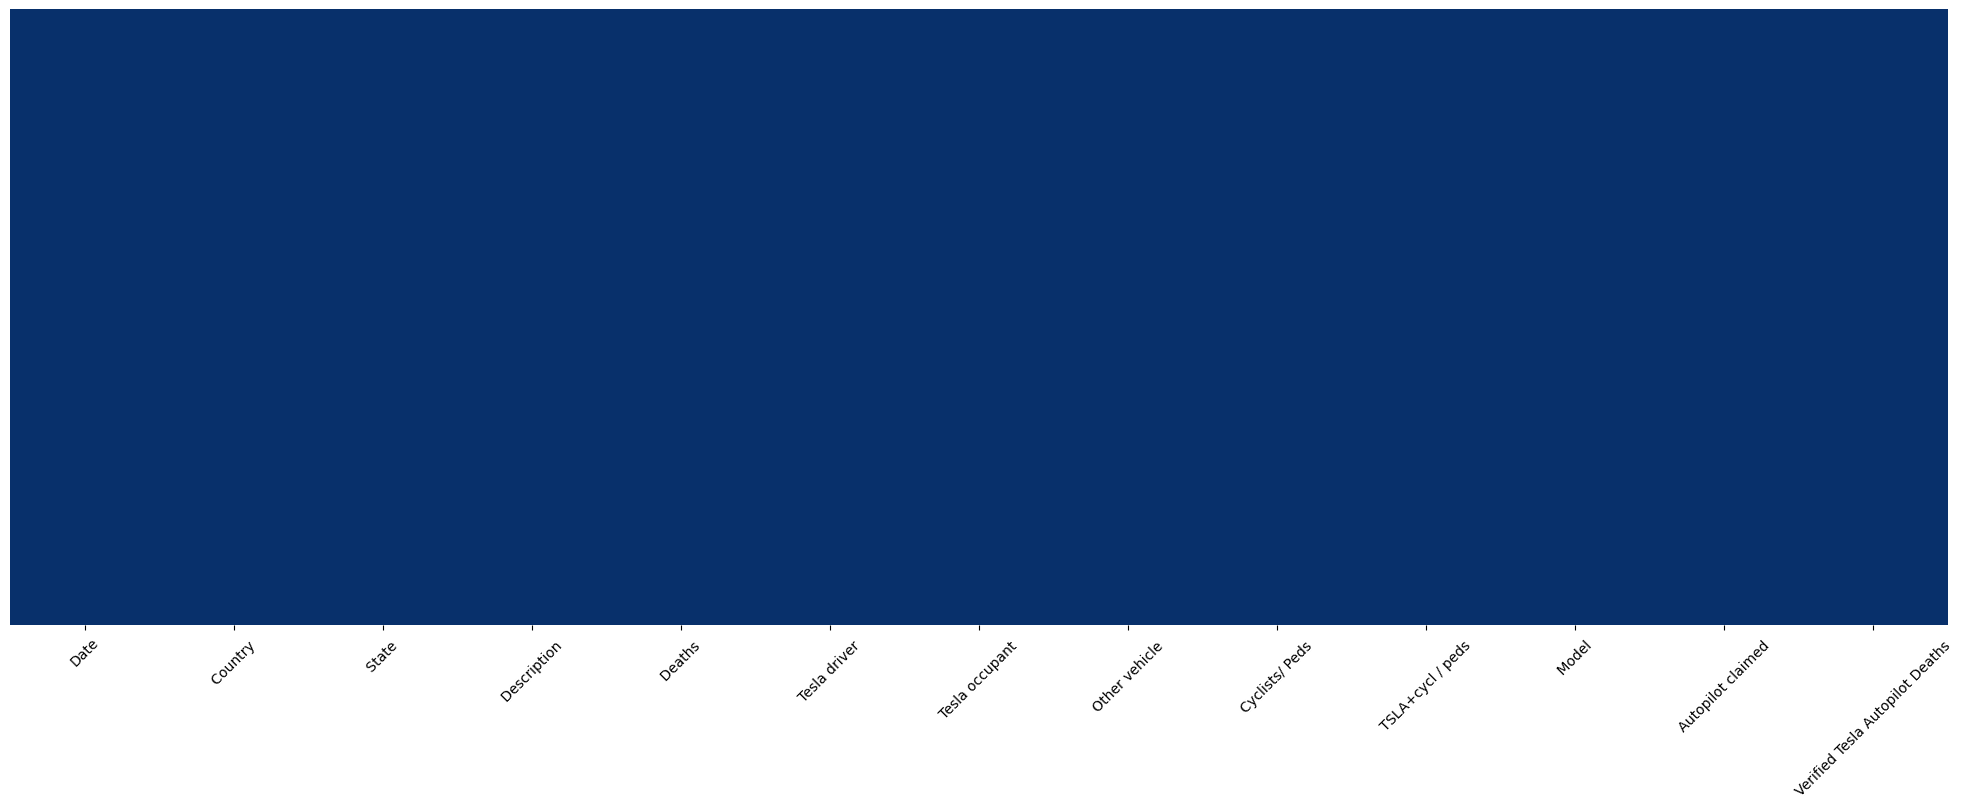

In [142]:
plt.figure(figsize=(25,8))
sns.heatmap(missing_values,cmap="Blues_r", cbar=False)
plt.tick_params(left=False, labelleft=False)
plt.xticks(rotation=45)
plt.show()

# Change the variable names in accordance to the python norms

In [143]:
data.columns = data.columns.str.strip()
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesla driver',
       'Tesla occupant', 'Other vehicle', 'Cyclists/ Peds', 'TSLA+cycl / peds',
       'Model', 'Autopilot claimed', 'Verified Tesla Autopilot Deaths'],
      dtype='object')

In [144]:
data.columns = data.columns.str.replace(" ","",regex=True).str.replace("[+/]","_", regex=True)

In [145]:
data.columns

Index(['Date', 'Country', 'State', 'Description', 'Deaths', 'Tesladriver',
       'Teslaoccupant', 'Othervehicle', 'Cyclists_Peds', 'TSLA_cycl_peds',
       'Model', 'Autopilotclaimed', 'VerifiedTeslaAutopilotDeaths'],
      dtype='object')

In [146]:
data.rename(columns={'Autopilotclaimed':"Claimed",'VerifiedTeslaAutopilotDeaths':"VTAD", 
                     'Teslaoccupant':"Tesla_Occupant",'Othervehicle':'Other_Vehicle','Tesladriver':'Tesla_Driver' }, inplace=True)

In [147]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 0 to 293
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            294 non-null    object 
 1   Country         294 non-null    object 
 2   State           294 non-null    object 
 3   Description     294 non-null    object 
 4   Deaths          294 non-null    float64
 5   Tesla_Driver    294 non-null    int64  
 6   Tesla_Occupant  294 non-null    int64  
 7   Other_Vehicle   294 non-null    int64  
 8   Cyclists_Peds   294 non-null    int64  
 9   TSLA_cycl_peds  294 non-null    int64  
 10  Model           294 non-null    object 
 11  Claimed         294 non-null    int64  
 12  VTAD            294 non-null    int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 32.2+ KB


In [148]:
data.Date = pd.to_datetime(data.Date)

In [149]:
data.loc[:, "event_year"] = data.Date.dt.year
data.loc[:,"event_month"] = data.Date.dt.month
data.loc[:,"event_day"] = data.Date.dt.day

## Year wise info

In [150]:
data["event_year"].value_counts()

event_year
2022    93
2021    58
2019    46
2020    39
2018    18
2016    15
2017    11
2015     5
2014     4
2023     3
2013     2
Name: count, dtype: int64

In [151]:
data = data[data["event_year"] != 2023]

In [152]:
vc = data["event_year"].value_counts()

vc = vc.sort_index()

vc

event_year
2013     2
2014     4
2015     5
2016    15
2017    11
2018    18
2019    46
2020    39
2021    58
2022    93
Name: count, dtype: int64

In [153]:
vc.values

array([ 2,  4,  5, 15, 11, 18, 46, 39, 58, 93])

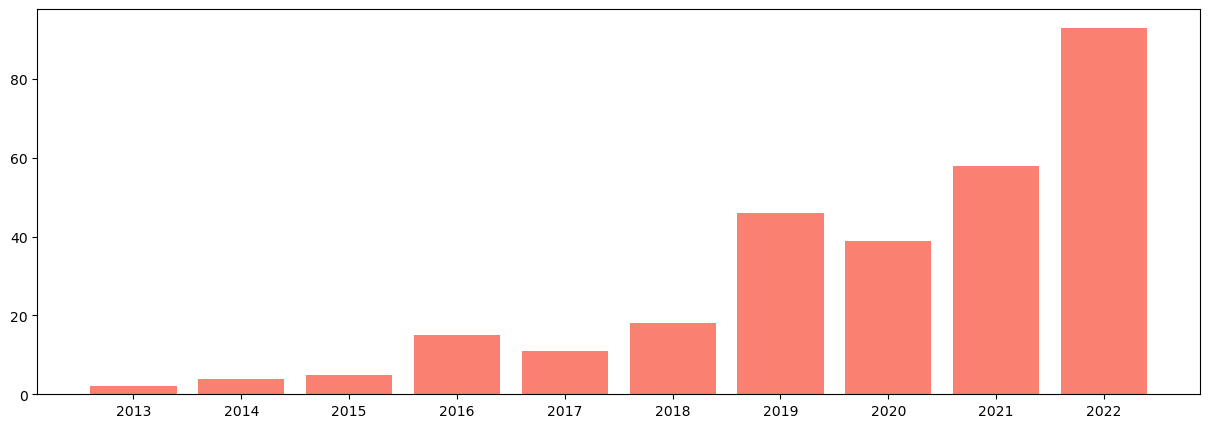

In [154]:
plt.figure(figsize=(15,5))
plt.bar(height=vc.values, x=vc.index,color="salmon")
plt.xticks(vc.index,vc.index)
plt.show()

In [155]:
data.shape

(291, 16)

In [156]:
data

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Claimed,VTAD,event_year,event_month,event_day
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,2022,12,19
5,2022-12-18,USA,CA,Tesla hit two other cars,1.0,0,1,0,0,0,-,0,0,2022,12,18
6,2022-12-17,USA,CA,Tesla hits pedestrian on highway,1.0,0,0,0,1,1,-,0,0,2022,12,17
7,2022-12-11,USA,CA,Tesla crashes into wall,1.0,1,0,0,0,0,-,0,0,2022,12,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,2014-07-14,USA,CA,Tesla kills motorcyclist,1.0,0,0,1,0,0,-,0,0,2014,7,14
290,2014-07-04,USA,CA,Thief crashes stolen Tesla,1.0,1,0,0,0,1,-,0,0,2014,7,4
291,2014-07-04,USA,CA,Tesla rear ends stopped car,3.0,0,0,3,0,0,-,0,0,2014,7,4
292,2013-11-02,USA,CA,Tesla kills cyclist,1.0,0,0,0,1,1,-,0,0,2013,11,2


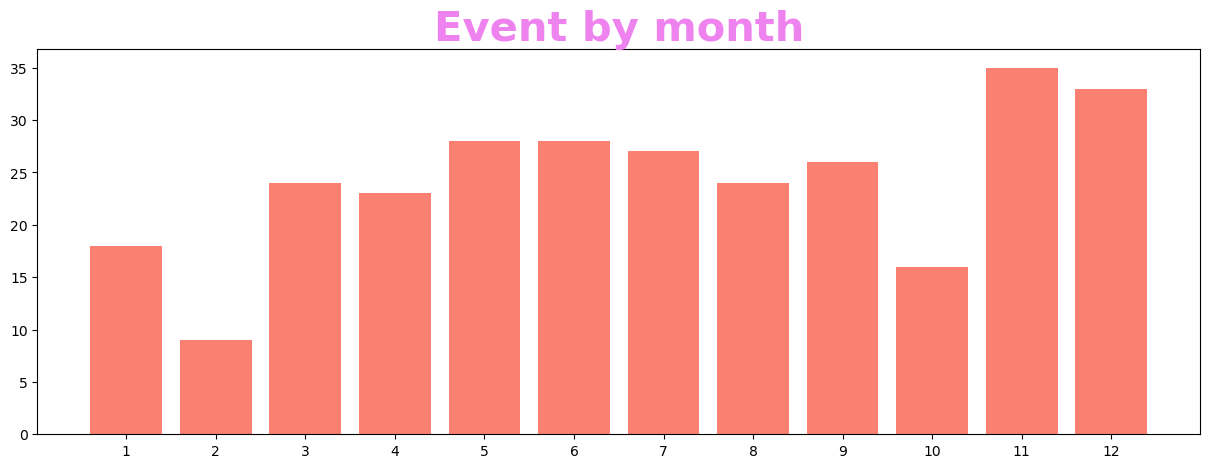

In [159]:
vc = data.event_month.value_counts()
vc = vc.sort_index()

plt.figure(figsize=(15,5))
plt.bar(height=vc.values, x=vc.index,color="salmon")
plt.xticks(vc.index,vc.index)
plt.title("Event by month",size=30,color="violet",weight="heavy")
plt.show()

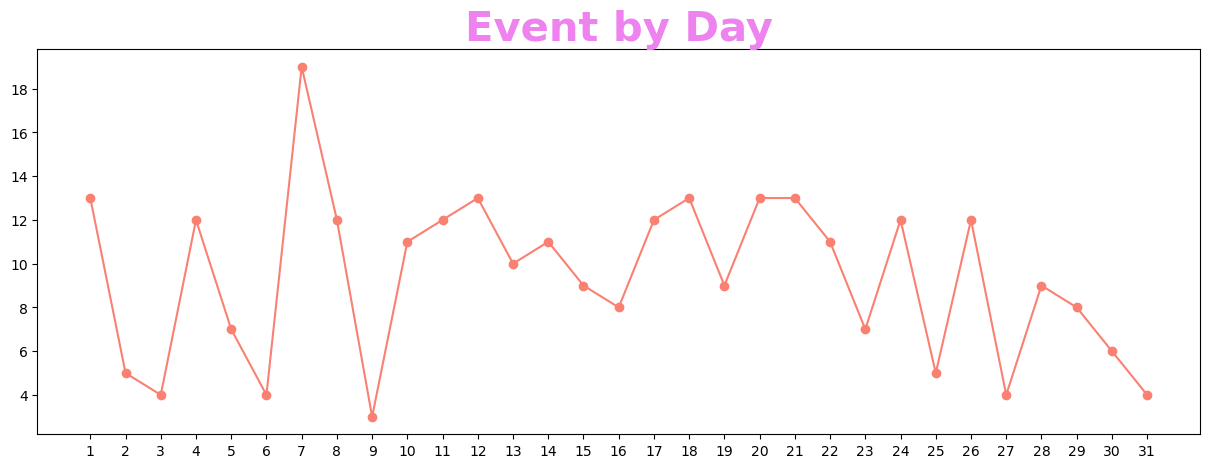

In [164]:
vc = data.event_day.value_counts()
vc = vc.sort_index()

plt.figure(figsize=(15,5))
plt.plot(vc.index,vc.values,color="salmon")
plt.scatter(vc.index,vc.values,color="salmon")
plt.xticks(vc.index,vc.index)
plt.title("Event by Day",size=30,color="violet",weight="heavy")
plt.show()

In [165]:
data.head()

,Date,Country,State,Description,Deaths,Tesla_Driver,Tesla_Occupant,Other_Vehicle,Cyclists_Peds,TSLA_cycl_peds,Model,Claimed,VTAD,event_year,event_month,event_day
3,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,0,0,0,1,-,0,0,2022,12,22
4,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,0,0,0,1,1,-,0,0,2022,12,19
5,2022-12-18,USA,CA,Tesla hit two other cars,1.0,0,1,0,0,0,-,0,0,2022,12,18
6,2022-12-17,USA,CA,Tesla hits pedestrian on highway,1.0,0,0,0,1,1,-,0,0,2022,12,17
7,2022-12-11,USA,CA,Tesla crashes into wall,1.0,1,0,0,0,0,-,0,0,2022,12,11


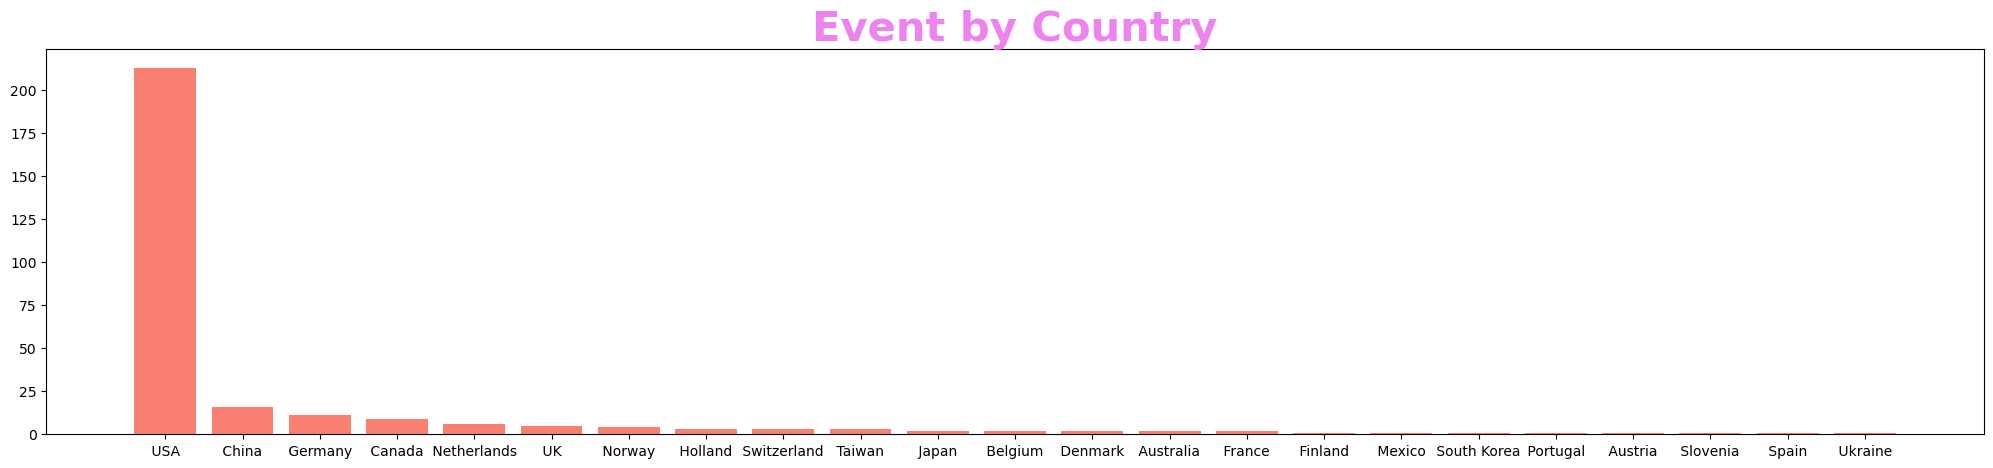

In [171]:
vc = data.Country.value_counts()


plt.figure(figsize=(25,5))
# plt.plot(vc.index,vc.values,color="salmon")
# plt.scatter(vc.index,vc.values,color="salmon")
plt.bar(vc.index,vc.values,color="salmon")
plt.xticks(vc.index,vc.index)
plt.title("Event by Country",size=30,color="violet",weight="heavy")
plt.show()

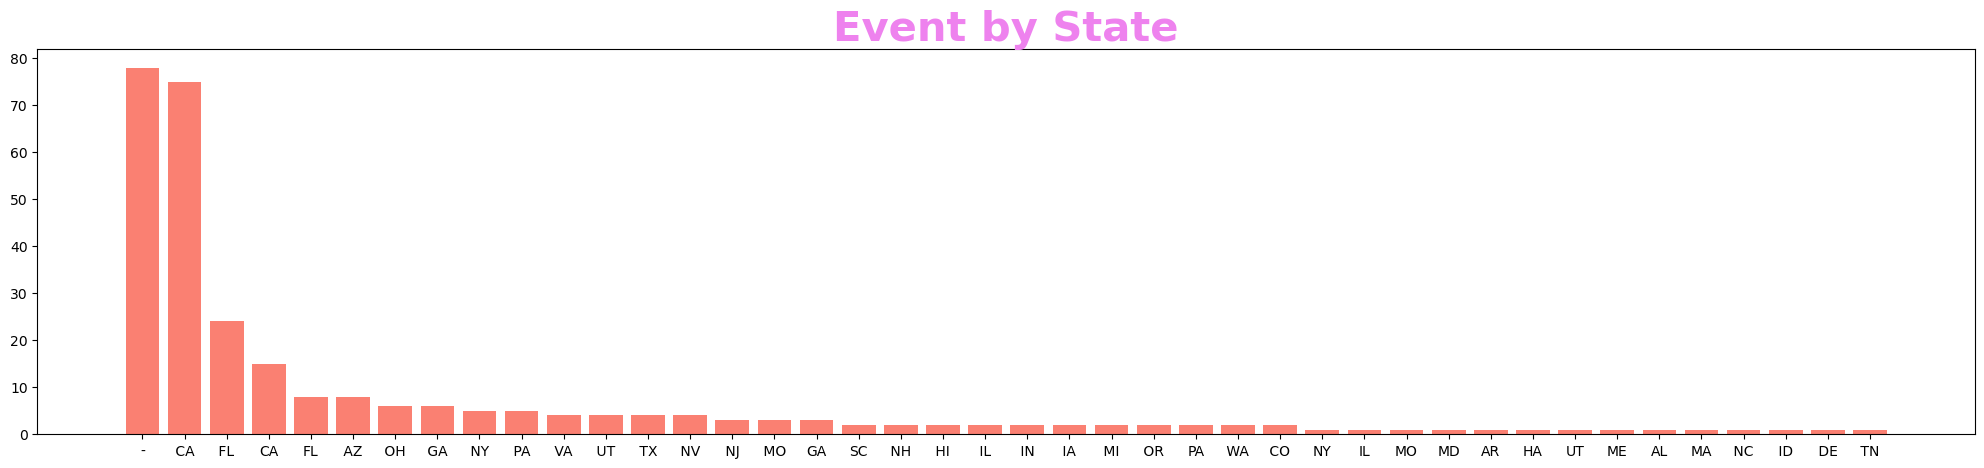

In [170]:
vc = data.State.value_counts()


plt.figure(figsize=(25,5))
# plt.plot(vc.index,vc.values,color="salmon")
# plt.scatter(vc.index,vc.values,color="salmon")
plt.bar(vc.index,vc.values,color="salmon")
plt.xticks(vc.index,vc.index)
plt.title("Event by State",size=30,color="violet",weight="heavy")
plt.show()

In [174]:
col_list = ['Deaths', 'Tesla_Driver','Tesla_Occupant', 'Other_Vehicle', 'Cyclists_Peds', 'TSLA_cycl_peds']

In [175]:
colr = ['salmon', 'mediumaquamarine', 'mediumpurple', 'goldenrod', 'silver', 'saddlebrown']

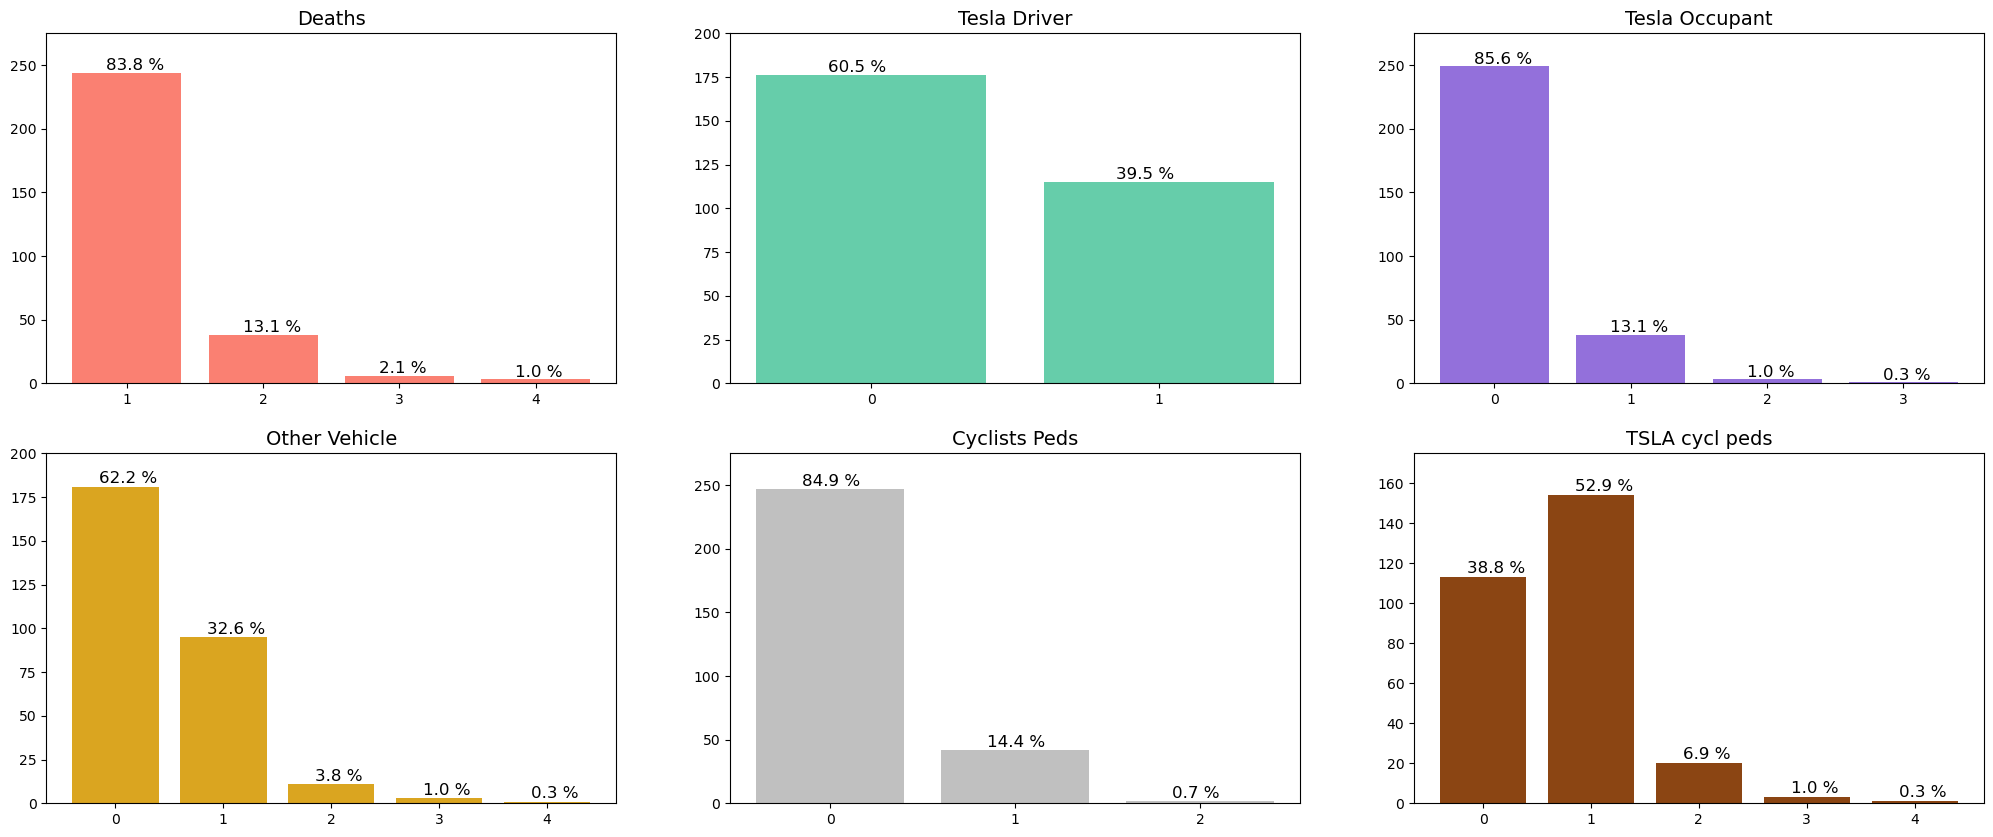

In [176]:
f,ax = plt.subplots(2,3, figsize = (25,10))
i,j,k = 0,0,0
for col in col_list:
  vc = data[col].value_counts()
  vc = vc.sort_index()
  perc = (vc/vc.sum()*100).round(1)
  #print(vc)
  ax[i,j].bar(x = vc.index, height = vc.values, color = colr[k])
  ax[i,j].set_title(col.replace("_", " "), size = 14)
  ax[i,j].set_xticks(vc.index)
  for l in vc.index:
    #print(l)
    ax[i,j].annotate("{} %".format(perc[l]), xy = (l-0.15,vc[l]+2), size = 12)
    ax[i,j].set_ylim(0,  25 * round(vc.max()/25)+25)
  j += 1
  k += 1
  if j == 3:
    j = 0
    i += 1

In [178]:
data["Model"].value_counts()

Model
-      178
S       45
 3      39
X       17
Y       10
 1       1
 2       1
Name: count, dtype: int64

In [179]:
data.Model = data.Model.str.strip()
data.Model = data.Model.replace("-", "0")

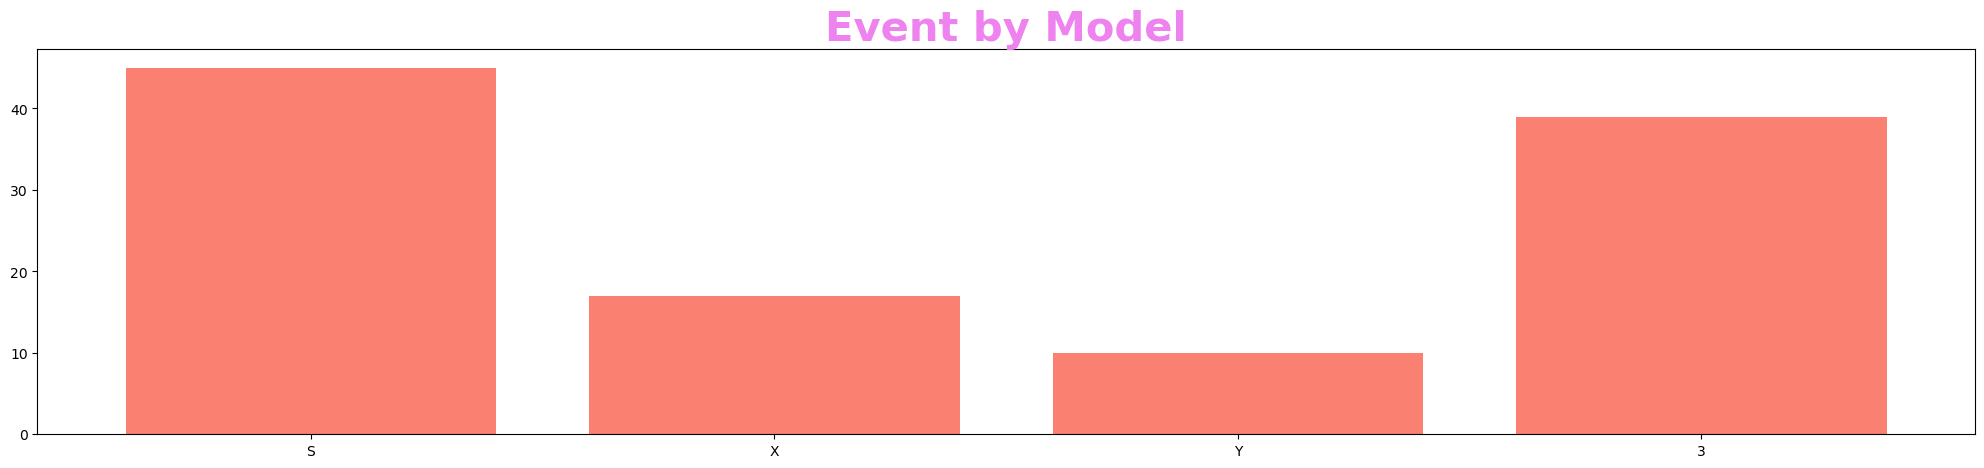

In [181]:
vc = data.Model.value_counts()

vc = vc[["S","X","Y","3"]]


plt.figure(figsize=(25,5))
# plt.plot(vc.index,vc.values,color="salmon")
# plt.scatter(vc.index,vc.values,color="salmon")
plt.bar(vc.index,vc.values,color="salmon")
plt.xticks(vc.index,vc.index)
plt.title("Event by Model",size=30,color="violet",weight="heavy")
plt.show()

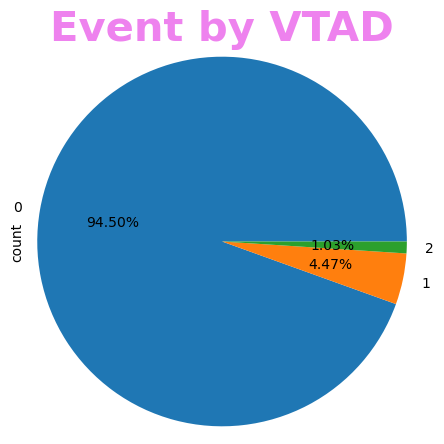

In [183]:
vc = data.VTAD.value_counts()




plt.figure(figsize=(25,5))


# plt.bar(vc.index,vc.values,color="salmon")
# plt.xticks(vc.index,vc.index)
vc.plot.pie(radius=1.2,autopct="%1.2f%%")

plt.title("Event by VTAD",size=30,color="violet",weight="heavy")
plt.show()